# EDA Online Retail 
Данные взяты с [The UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail)

### О данных 
Данные содержат информацию  о транзакциях, произошедших в период с 01/12/2010 по 09/12/2011 для зарегистрированного в Великобритании интернет-магазина. Также указано, что основными товарами компаниия являются  уникальные подарки на все случаи жизни и многие клиенты компании являются оптовиками.

### Столбцы и информация, хранящееся в них:
- **`InvoiceNo`** - Номер транзакции(**'C'** в начале номера означает отмену транзакции)
- **`StockCode`** - Код продукта
- **`Description`** - Описание продукта
- **`Quantity`** - Количество купленных единиц товара
- **`InvoiceDate`** - Дата и время транзакции
- **`UnitPrice`** - Цена за единицу товара(в фунтах стерлингах)
- **`CustomerID`** - ID покупателя
- **`Country`** - Страна, в которой проживает покупатель

### Задачи 
1. Загрузка и предобработка данных.
2. Поиск закономерностей и визуализация
3. Подсчет метрик
4. Когортный анализ
5. RFM-аналз.

### 1. Загрузка и предобработка данных

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import scipy
sns.set(style="whitegrid", color_codes=True)

%matplotlib inline

import warnings
warnings.simplefilter('ignore')

In [3]:
data = pd.read_excel('Online Retail.xlsx')
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Избавимся от строк с пропущенными значениями в колонке CustomerID, преобразуем типы данных в столбцах InvoiceDate и CustomerId и создадим столбец FullPrice(полная сумма покупки)

In [8]:
data = data[data['CustomerID'].notna()]

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['CustomerID'] = data['CustomerID'].astype('int64')

data['FullPrice'] = data['Quantity'] * data['UnitPrice']

Данные по отменненным заказам, сообщают о том, что был такой заказ, в нем было столько-то товаров с какими-то ценными и их отменили, то есть магазин не потерял и не получил прибыль.
Стоит рассматривать эти данные отдельно от выполненных транзаций.

In [10]:
data_with_only_cancels = data[data.InvoiceNo.str.find('c').notna()] # данные только об отменах
data_with_only_cancels

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,FullPrice
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96
...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,-9.13
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,-224.69
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,-54.75
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,-1.25


In [11]:
data_without_cancels =  data[data.InvoiceNo.str.find('c').isna()]
data_without_cancels

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,FullPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [12]:
data_without_cancels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  int64         
 7   Country      397924 non-null  object        
 8   FullPrice    397924 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


In [13]:
data_without_cancels[['Quantity','UnitPrice','FullPrice']].describe() #Видим, что есть товары и заказы, цена которых равна нулю

,Quantity,UnitPrice,FullPrice
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,22.394749
std,180.420210,22.096788,309.055588
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [14]:
data_without_cancels[data_without_cancels['UnitPrice'] == 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,FullPrice
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany,0.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom,0.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE,0.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0


Часть товаров имеет уникальный код

In [16]:
data_without_cancels[data_without_cancels['StockCode'].astype("str").str.isalpha()]['StockCode'].unique()

array(['POST', 'M', 'PADS', 'DOT'], dtype=object)

### 2. Поиск закономерностей и визуализация

In [18]:
data_without_cancels[['Quantity', 'UnitPrice','FullPrice']].describe()

,Quantity,UnitPrice,FullPrice
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,22.394749
std,180.420210,22.096788,309.055588
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [19]:
print(f'Всего проведено транзакций: {data_without_cancels['InvoiceNo'].nunique()}')
print(f'Количество уникальных клиентов: {data_without_cancels['CustomerID'].nunique()}')
print(f'Количество стран, в которых проживают клиенты онйлан магазина: {data_without_cancels['Country'].nunique()}')

Всего проведено транзакций: 18536
Количество уникальных клиентов: 4339
Количество стран, в которых проживают клиенты онйлан магазина: 37


### Транзакции

In [21]:
purchases = data_without_cancels.groupby('InvoiceNo')[['Quantity','FullPrice']].sum().reset_index()
purchases = purchases.sort_values(by='FullPrice')
purchases

,InvoiceNo,Quantity,FullPrice
2721,543599,16,0.00
17360,578841,12540,0.00
11301,564651,576,0.00
12848,568384,1,0.00
13792,570554,1,0.38
...,...,...,...
8112,556917,15049,22775.93
12419,567423,12572,31698.16
7926,556444,60,38970.00
1909,541431,74215,77183.60


In [22]:
purchases.describe()

,InvoiceNo,Quantity,FullPrice
count,18536.000000,18536.000000,18536.000000
mean,559527.999407,279.547691,480.762187
std,13040.283892,976.796524,1678.029352
min,536365.000000,1.000000,0.000000
25%,548352.500000,74.000000,157.930000
50%,559818.500000,155.000000,303.020000
75%,570834.500000,291.000000,471.660000
max,581587.000000,80995.000000,168469.600000


In [23]:
purchases[purchases['FullPrice'] == 0]

,InvoiceNo,Quantity,FullPrice
2721,543599,16,0.0
17360,578841,12540,0.0
11301,564651,576,0.0
12848,568384,1,0.0


In [24]:
purchase_non_zero = purchases[purchases['FullPrice'] > 0]
purchase_non_zero[purchase_non_zero['FullPrice'] == purchase_non_zero['FullPrice'].min()]

,InvoiceNo,Quantity,FullPrice
13792,570554,1,0.38


In [25]:
cancels = data_with_only_cancels.groupby('InvoiceNo')[['Quantity','FullPrice']].sum().reset_index()
cancels = cancels.sort_values(by='FullPrice')
cancels.describe()

,Quantity,FullPrice
count,3654.000000,3654.000000
mean,-75.207444,-167.307633
std,1836.212969,3179.611324
min,-80995.000000,-168469.600000
25%,-11.000000,-37.337500
50%,-4.000000,-16.000000
75%,-1.000000,-7.650000
max,-1.000000,-0.390000


In [26]:
cancels

,InvoiceNo,Quantity,FullPrice
3649,C581484,-80995,-168469.60
422,C541433,-74215,-77183.60
1701,C556445,-1,-38970.00
1208,C550456,-9014,-22998.40
2880,C570556,-6480,-11816.64
...,...,...,...
1997,C559830,-1,-0.48
840,C545847,-1,-0.42
660,C543780,-1,-0.42
2861,C570331,-1,-0.39


In [27]:
def colors_from_values(values, palette_name):
    # normalize the values to range [0, 1]
    normalized = (values - min(values)) / (max(values) - min(values))
    # convert to indices
    indices = np.round(normalized * (len(values) - 1)).astype(np.int32)
    # use the indices to get the colors
    palette = sns.color_palette(palette_name, len(values))
    return np.array(palette).take(indices, axis=0)

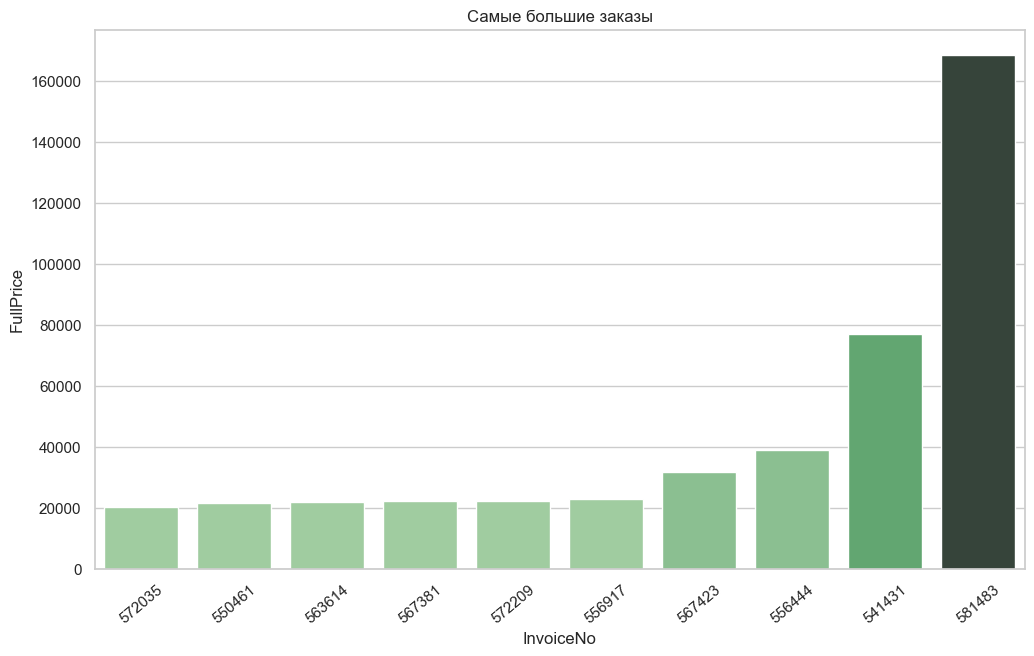

In [28]:
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

top = purchases.tail(10)
top['InvoiceNo'] = top['InvoiceNo'].astype(str)
sns.barplot(y=top['FullPrice'],x=top['InvoiceNo'], palette=colors_from_values(top['FullPrice'], "Greens_d"))
plt.xticks(rotation=40)
plt.title('Самые большие заказы')
plt.show()

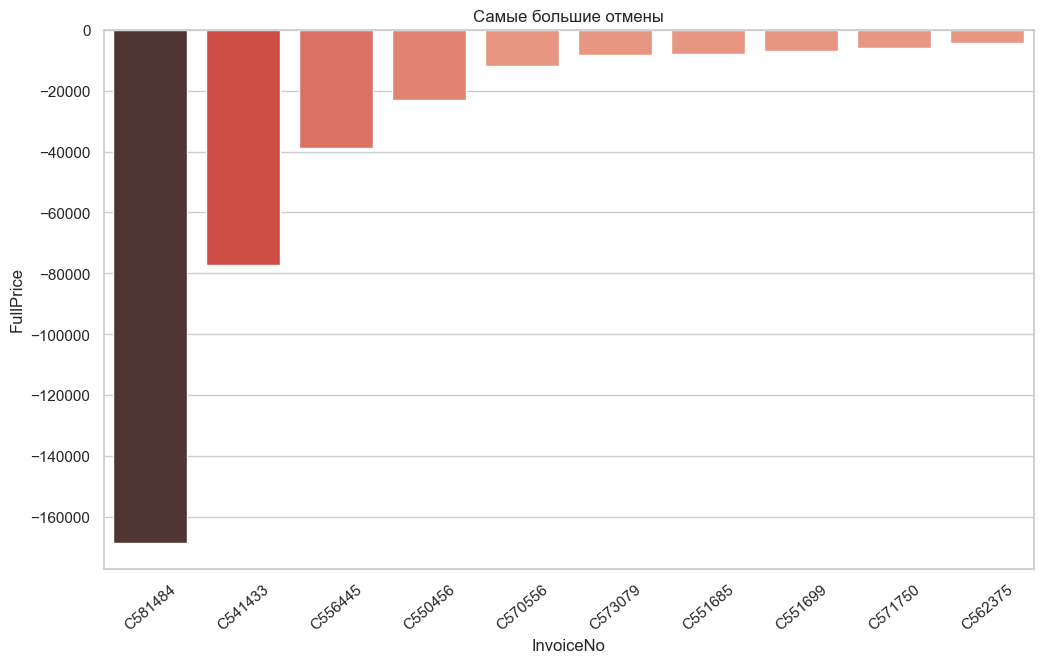

In [29]:
least = cancels.head(10)
least['InvoiceNo'] = least['InvoiceNo'].astype(str)
sns.barplot(y=least['FullPrice'],x=least['InvoiceNo'], palette=colors_from_values(abs(least['FullPrice']), "Reds_d"))
plt.xticks(rotation=40)
plt.title('Самые большие отмены')
plt.show()

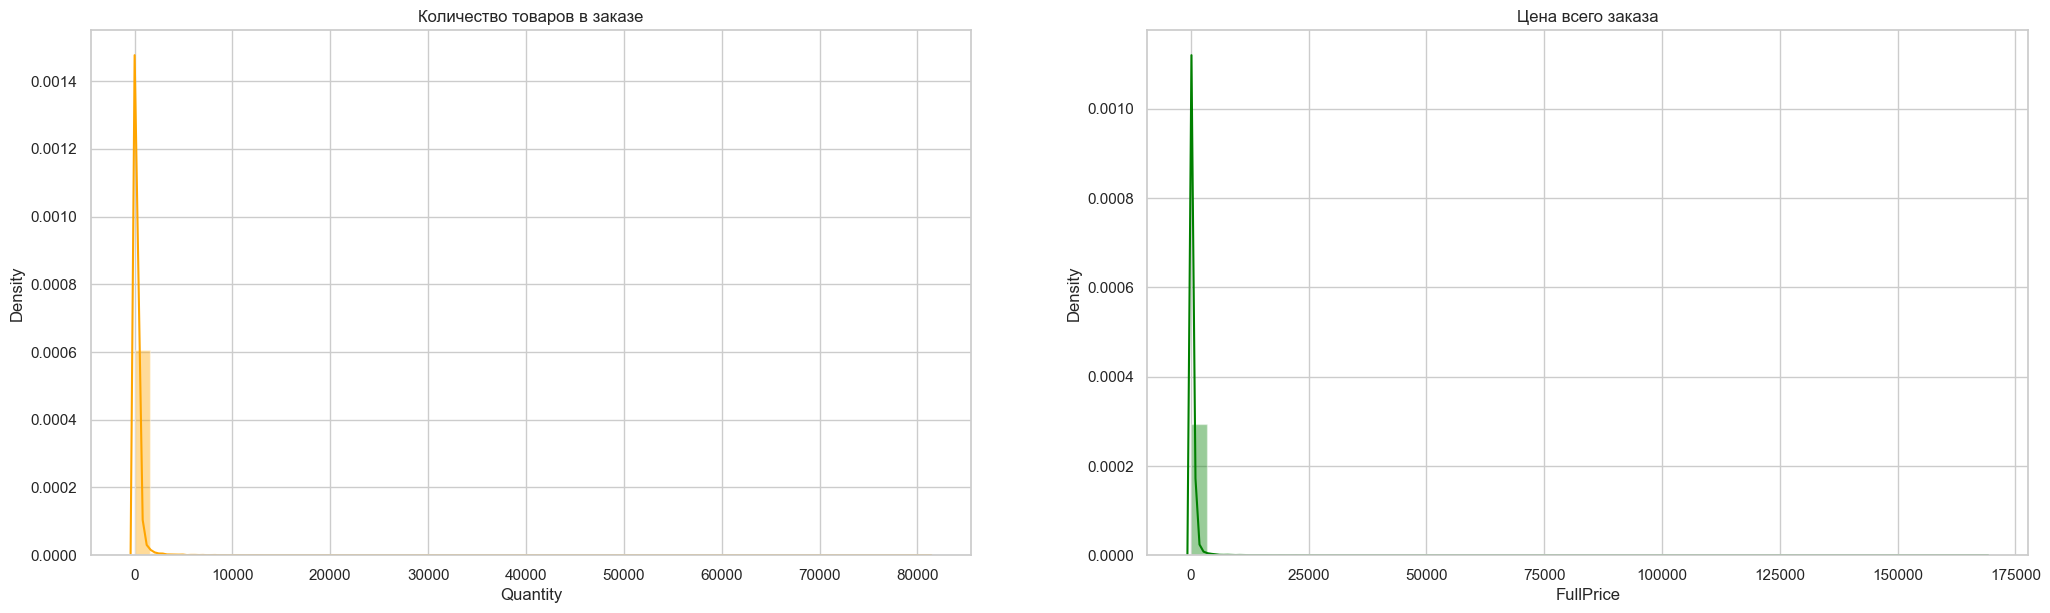

In [30]:
plt.rcParams['figure.figsize'] = (25, 15)
plt.rcParams['font.size'] = 12

plt.subplot(2, 2, 1)
sns.distplot(purchase_non_zero['Quantity'],  color = 'orange')
plt.title('Количество товаров в заказе')

plt.subplot(2, 2, 2)
sns.distplot(purchase_non_zero['FullPrice'],  color = 'green')
plt.title('Цена всего заказа')
plt.show()

Видим, что распределение количества товаров и цен транзакций имеет большой показатель ассиметрии и выбросы, находящиеся далеко от среднего значения

In [32]:
purchase_non_zero['FullPrice'].skew()

62.139131028412905

Попробуем отнормировать оба распределения с помошью логарифмического преобразования

In [34]:
purchase_non_zero['Quantity'] = np.log1p(purchase_non_zero['Quantity'])

purchase_non_zero['FullPrice'] = np.log1p(purchase_non_zero['FullPrice'])



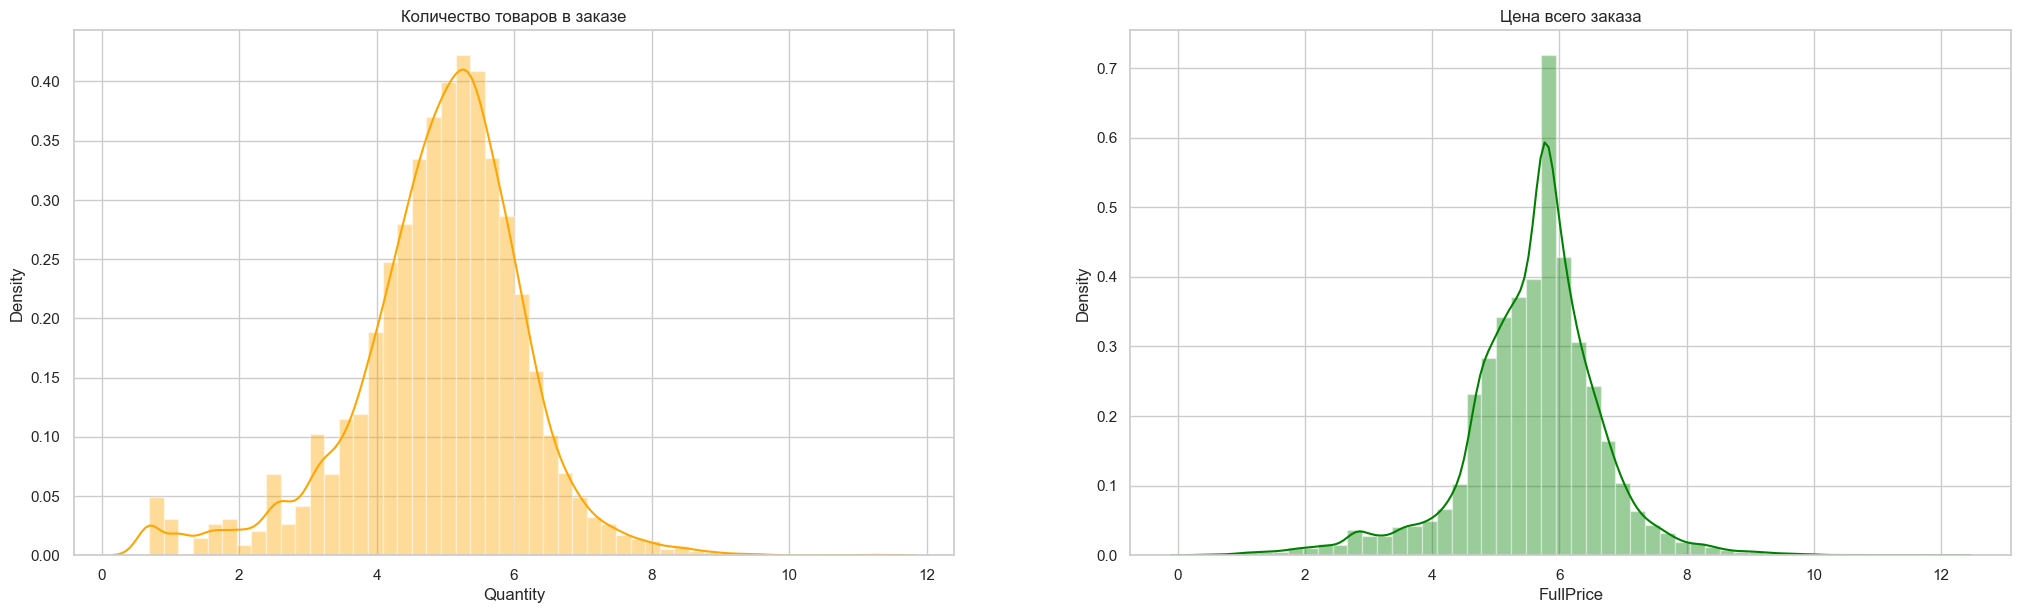

In [35]:
plt.rcParams['figure.figsize'] = (25, 15)
plt.rcParams['font.size'] = 12

plt.subplot(2, 2, 1)
sns.distplot(purchase_non_zero['Quantity'],  color = 'orange')
plt.title('Количество товаров в заказе')

plt.subplot(2, 2, 2)
sns.distplot(purchase_non_zero['FullPrice'],  color = 'green')
plt.title('Цена всего заказа')
plt.show()

Видим, что преобразованые распределения близки к нормальному, но имеют перекосы в левой части.

### Покупатели

In [38]:
customers = data_without_cancels.groupby('CustomerID').agg({'Quantity': 'sum','FullPrice':'sum','InvoiceNo':'count'}).reset_index()
customers = customers.sort_values(by='FullPrice')
customers.rename(columns={'InvoiceNo':'PurchaseCount'},inplace=True)
customers['CustomerID'] = customers['CustomerID'].astype('str')
customers

,CustomerID,Quantity,FullPrice,PurchaseCount
685,13256,12540,0.00,1
3218,16738,3,3.75,1
1794,14792,2,6.20,2
3015,16454,3,6.90,2
4099,17956,1,12.75,1
...,...,...,...,...
1880,14911,80515,143825.06,5677
3009,16446,80997,168472.50,3
3729,17450,69993,194550.79,337
4202,18102,64124,259657.30,431


In [39]:
customers.describe()

,Quantity,FullPrice,PurchaseCount
count,4339.000000,4339.000000,4339.000000
mean,1194.214335,2053.793018,91.708689
std,5055.603049,8988.248381,228.792852
min,1.000000,0.000000,1.000000
25%,160.000000,307.245000,17.000000
50%,379.000000,674.450000,41.000000
75%,993.000000,1661.640000,100.000000
max,197491.000000,280206.020000,7847.000000


In [40]:
customers['FullPrice'][-10:]

0        77183.60
2703     81024.84
3772     91062.38
1334    117379.63
55      124914.53
1880    143825.06
3009    168472.50
3729    194550.79
4202    259657.30
1690    280206.02
Name: FullPrice, dtype: float64

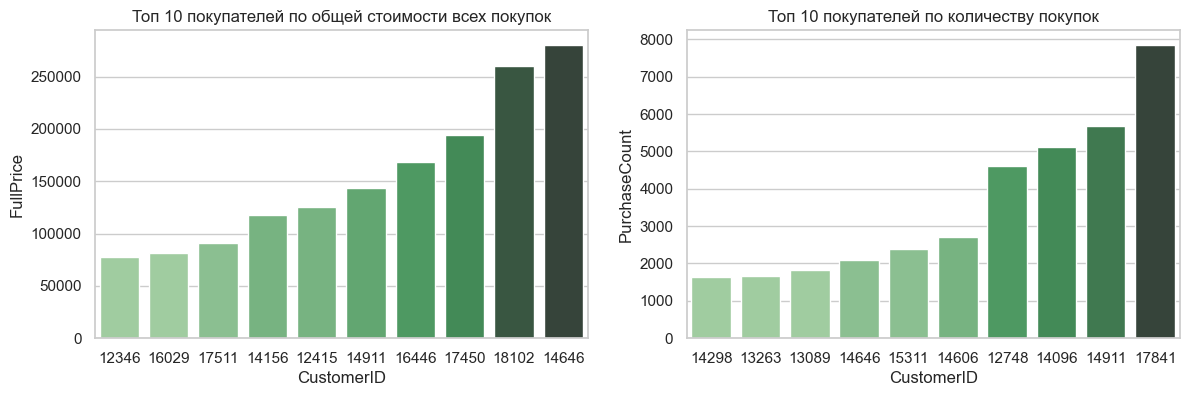

In [41]:
fig, ax = plt.subplots(1,2, figsize=(14, 4) )
sns.barplot(y=customers['FullPrice'][-10:],x=customers['CustomerID'][-10:], palette=colors_from_values(customers['FullPrice'][-10:], "Greens_d"),ax=ax[0])
ax[0].set_title('Топ 10 покупателей по общей стоимости всех покупок')

customers_count = customers.sort_values(by='PurchaseCount')
sns.barplot(y=customers_count['PurchaseCount'][-10:],x=customers_count['CustomerID'][-10:], palette=colors_from_values(customers_count['PurchaseCount'][-10:], "Greens_d"),ax=ax[1])
ax[1].set_title('Топ 10 покупателей по количеству покупок')

plt.show()

### Страны

In [42]:
countries = data_without_cancels.groupby('Country').agg({'InvoiceNo':'count','FullPrice':'sum'}).sort_values(by='FullPrice',ascending=False)
countries.head(10)

,InvoiceNo,FullPrice
Country,,
United Kingdom,354345,7308391.554
Netherlands,2363,285446.340
EIRE,7238,265545.900
Germany,9042,228867.140
France,8342,209024.050
Australia,1185,138521.310
Spain,2485,61577.110
Switzerland,1842,56443.950
Belgium,2031,41196.340


In [43]:
countries.describe()

,InvoiceNo,FullPrice
count,37.000000,3.700000e+01
mean,10754.702703,2.408489e+05
std,58097.507836,1.196639e+06
min,9.000000,1.459200e+02
25%,112.000000,2.667070e+03
50%,330.000000,1.359038e+04
75%,1185.000000,3.837833e+04
max,354345.000000,7.308392e+06


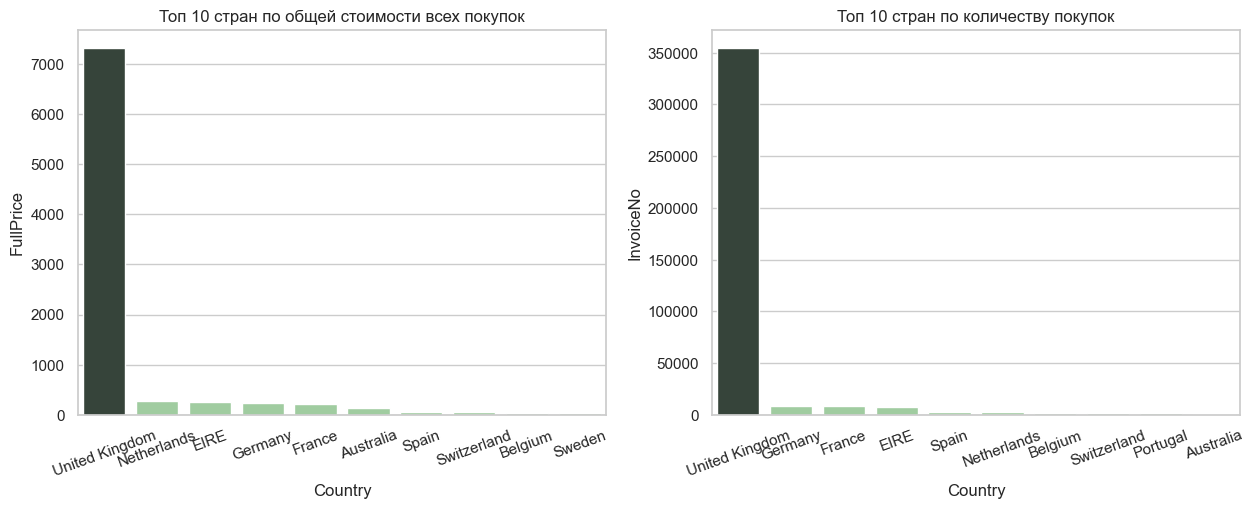

In [44]:
fig, ax = plt.subplots(1,2, figsize=(15, 5) )
sns.barplot(y=countries['FullPrice'][:10] / 1000,x=countries.index[:10], palette=colors_from_values(countries['FullPrice'][:10], "Greens_d"),ax=ax[0])
ax[0].set_title('Топ 10 стран по общей стоимости всех покупок')
ax[0].tick_params(axis='x', labelrotation=20)

countries_count= countries.sort_values(by='InvoiceNo',ascending=False)
sns.barplot(y=countries_count['InvoiceNo'][:10],x=countries_count.index[:10], palette=colors_from_values(countries_count['InvoiceNo'][:10], "Greens_d"),ax=ax[1])
ax[1].set_title('Топ 10 стран по количеству покупок')
ax[1].tick_params(axis='x', labelrotation=20)

plt.show()

Большинство покупок сделано в Англии

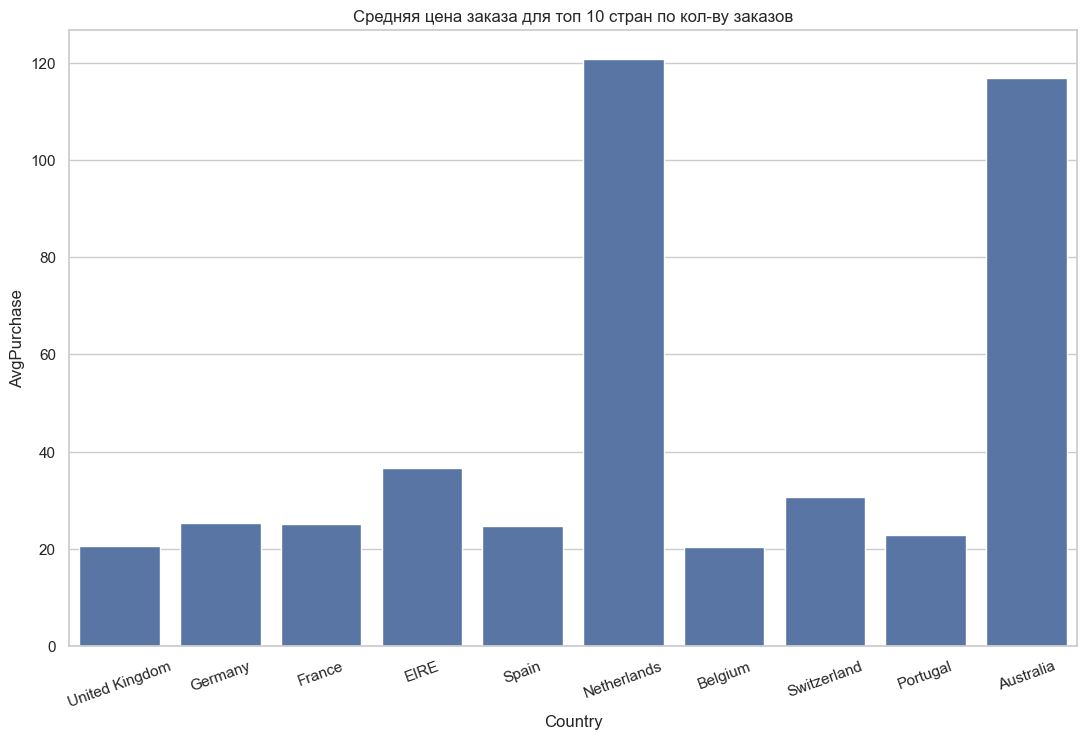

In [45]:
plt.rcParams['figure.figsize'] = (13, 8)
countries_count['AvgPurchase'] = countries_count['FullPrice'] / countries_count['InvoiceNo']
sns.barplot(y=countries_count['AvgPurchase'][:10],x=countries_count.index[:10])
plt.title('Средняя цена заказа для топ 10 стран по кол-ву заказов')
plt.xticks(rotation=20)
plt.show()

### Временные промежутки

In [46]:
date_df =  data_without_cancels[['InvoiceNo','InvoiceDate']]
date_df['day_of_week'] = date_df['InvoiceDate'].dt.day_name()
date_df['month'] = date_df['InvoiceDate'].dt.month_name()
date_df['hour'] = date_df['InvoiceDate'].dt.hour
date_df['year'] = date_df['InvoiceDate'].dt.year
date_df['date'] = pd.to_datetime(date_df['InvoiceDate'].dt.strftime('%Y-%m-%d'))
date_df

,InvoiceNo,InvoiceDate,day_of_week,month,hour,year,date
0,536365,2010-12-01 08:26:00,Wednesday,December,8,2010,2010-12-01
1,536365,2010-12-01 08:26:00,Wednesday,December,8,2010,2010-12-01
2,536365,2010-12-01 08:26:00,Wednesday,December,8,2010,2010-12-01
3,536365,2010-12-01 08:26:00,Wednesday,December,8,2010,2010-12-01
4,536365,2010-12-01 08:26:00,Wednesday,December,8,2010,2010-12-01
...,...,...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,Friday,December,12,2011,2011-12-09
541905,581587,2011-12-09 12:50:00,Friday,December,12,2011,2011-12-09
541906,581587,2011-12-09 12:50:00,Friday,December,12,2011,2011-12-09
541907,581587,2011-12-09 12:50:00,Friday,December,12,2011,2011-12-09


In [47]:
temp_month = date_df.groupby(['year','month'])['InvoiceNo'].nunique().reset_index()
month = temp_month.groupby(['month'])['InvoiceNo'].mean()
month = month.reindex(['January', 'February', 'March', 'April', 'May', 'June', 
                 'July', 'August', 'September', 'October', 'November',
                 'December'] )

temp_day_of_week= date_df.groupby(['date','day_of_week'])['InvoiceNo'].nunique().reset_index()
day_of_week = temp_day_of_week.groupby(['day_of_week'])['InvoiceNo'].mean()
day_of_week = day_of_week.reindex(['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'],fill_value=0)

temp_hour= date_df.groupby(['date','hour'])['InvoiceNo'].nunique().reset_index()
hour = temp_hour.groupby(['hour'])['InvoiceNo'].mean()


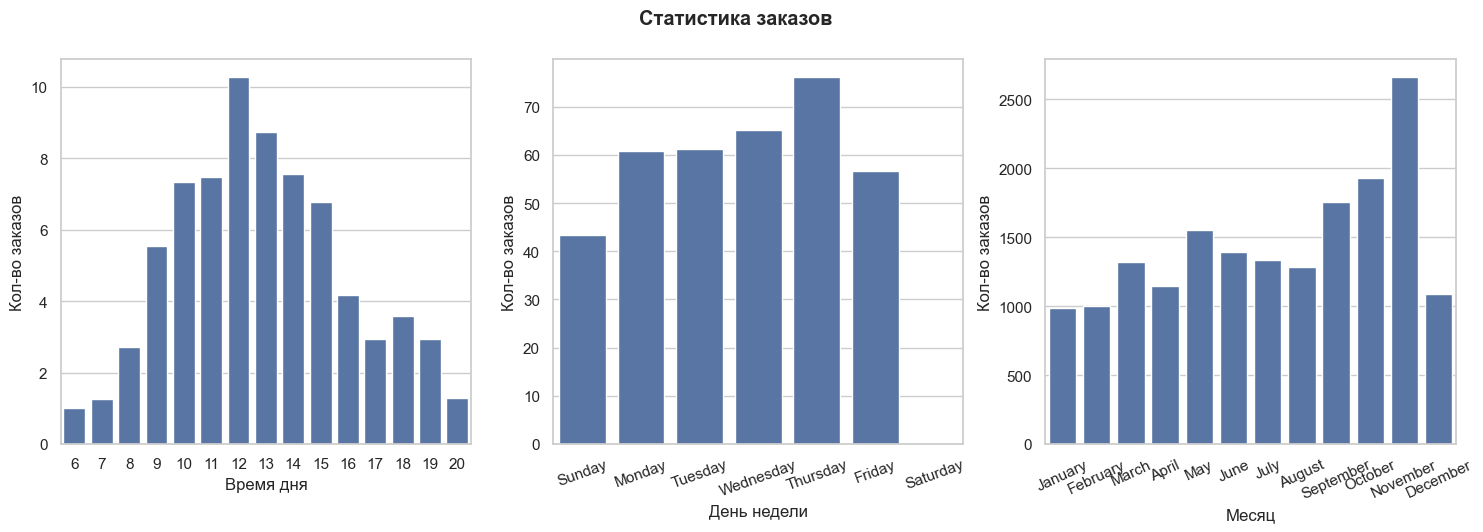

In [48]:
fig, ax = plt.subplots(1,3, figsize=(18, 5) )

fig.suptitle('Статистика заказов', fontweight='heavy')

sns.barplot(hour,ax=ax[0],)
ax[0].set_xlabel('Время дня')
ax[0].set_ylabel('Кол-во заказов')

sns.barplot(day_of_week,ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=20)
ax[1].set_xlabel('День недели')
ax[1].set_ylabel('Кол-во заказов')

sns.barplot(month,ax=ax[2])
ax[2].tick_params(axis='x', labelrotation=25)
ax[2].set_xlabel('Месяц')
ax[2].set_ylabel('Кол-во заказов')

plt.show()

#### Время дня
С 6 часов дня количество заказов расет и достигает своего пика в 12 часов, а потом постепенно снижается до 20 часов, после чего продажи прекращаются
#### Дни недели
В воскресенье и пятницу наименьшее кол-во заказов, в понедельник-среду примерно одинаковое кол-во, а в четверг идет пик
#### Месяцы
Видим, что пик продаж достигается осенью, в ноября, а зимой достигается минимум

### Когортный анализ удержания

In [50]:
cohorts = data[['CustomerID', 'InvoiceDate']]

cohorts['order_month'] = cohorts.InvoiceDate.apply(lambda x: x.strftime('%Y-%m'))

join_month = pd.DataFrame(cohorts.groupby('CustomerID')['InvoiceDate'].min().apply(lambda x: x.strftime('%Y-%m'))).rename(columns={'InvoiceDate': 'join_month'})
cohorts = pd.merge(cohorts,join_month, on=['CustomerID'])

cohorts.head()

,CustomerID,InvoiceDate,order_month,join_month
0,17850,2010-12-01 08:26:00,2010-12,2010-12
1,17850,2010-12-01 08:26:00,2010-12,2010-12
2,17850,2010-12-01 08:26:00,2010-12,2010-12
3,17850,2010-12-01 08:26:00,2010-12,2010-12
4,17850,2010-12-01 08:26:00,2010-12,2010-12


In [51]:
cohorts_1 = cohorts.groupby(['join_month', 'order_month']) \
                   .agg({'CustomerID':pd.Series.nunique, 'InvoiceDate':pd.Series.count}) \
                    .rename(columns={'CustomerID':'total_customers','InvoiceDate':'total_orders'})
cohorts_1

total_customers  total_orders
join_month order_month                               
2010-12    2010-12                  948         26850
           2011-01                  362         10881
           2011-02                  317          9183
           2011-03                  367         12111
           2011-04                  341         10092
...                                 ...           ...
2011-10    2011-11                   93          3643
           2011-12                   46           907
2011-11    2011-11                  321         11249
           2011-12                   43          1152
2011-12    2011-12                   41           996

[91 rows x 2 columns]

In [52]:
cohorts_2 = cohorts_1.reset_index()
cohorts_2['cohort_period'] = cohorts_2.groupby('join_month')['order_month'].rank(method='dense').astype('int16')
cohorts_2.set_index(['cohort_period', 'join_month'], inplace=True)
cohorts_2.head()

,,order_month,total_customers,total_orders
cohort_period,join_month,,,
1,2010-12,2010-12,948,26850
2,2010-12,2011-01,362,10881
3,2010-12,2011-02,317,9183
4,2010-12,2011-03,367,12111
5,2010-12,2011-04,341,10092


In [53]:
cohort_group_size = cohorts_2['total_customers'].groupby(level=1).first()
cohorts_2['total_customers'].unstack(0)

cohort_period,1,2,3,4,5,6,7,8,9,10,11,12,13
join_month,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
cohort_group_size

join_month
2010-12    948
2011-01    421
2011-02    380
2011-03    440
2011-04    299
2011-05    279
2011-06    235
2011-07    191
2011-08    167
2011-09    298
2011-10    352
2011-11    321
2011-12     41
Name: total_customers, dtype: int64

In [55]:
retention_rate = cohorts_2['total_customers'].unstack(0).divide(cohort_group_size, axis=0)
retention_rate

cohort_period,1,2,3,4,5,6,7,8,9,10,11,12,13
join_month,,,,,,,,,,,,,
2010-12,1.0,0.381857,0.334388,0.387131,0.359705,0.396624,0.379747,0.354430,0.354430,0.394515,0.373418,0.500000,0.274262
2011-01,1.0,0.239905,0.282660,0.242280,0.327791,0.299287,0.261283,0.256532,0.311164,0.346793,0.368171,0.149644,NaN
2011-02,1.0,0.247368,0.192105,0.278947,0.268421,0.247368,0.255263,0.281579,0.257895,0.313158,0.092105,NaN,NaN
2011-03,1.0,0.190909,0.254545,0.218182,0.231818,0.177273,0.263636,0.238636,0.288636,0.088636,NaN,NaN,NaN
2011-04,1.0,0.227425,0.220736,0.210702,0.207358,0.237458,0.230769,0.260870,0.083612,NaN,NaN,NaN,NaN
2011-05,1.0,0.236559,0.172043,0.172043,0.215054,0.243728,0.265233,0.103943,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.208511,0.187234,0.272340,0.246809,0.336170,0.102128,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.209424,0.204188,0.230366,0.272251,0.115183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.251497,0.251497,0.251497,0.137725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


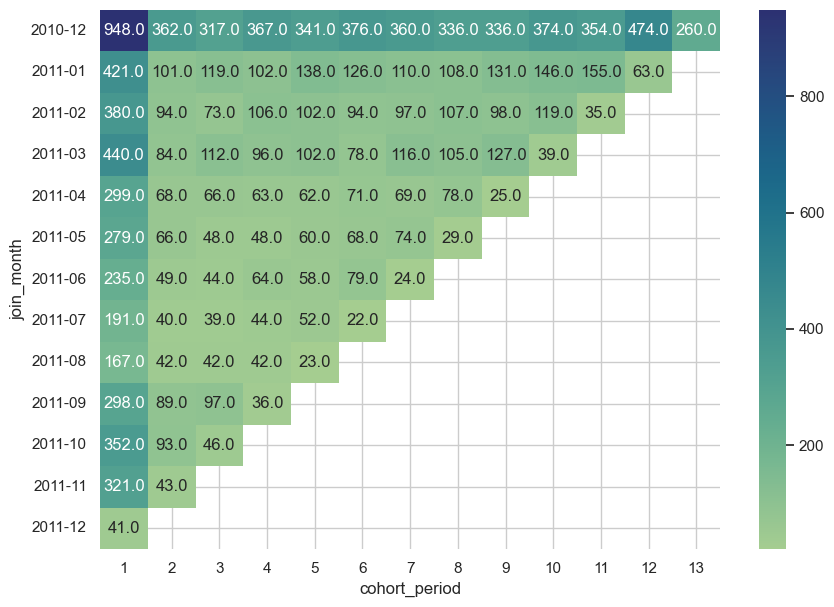

In [56]:
plt.figure(figsize=(10, 7))
sns.heatmap(cohorts_2['total_customers'].unstack(0),annot=True,cmap="crest", fmt=".1f")
plt.show()

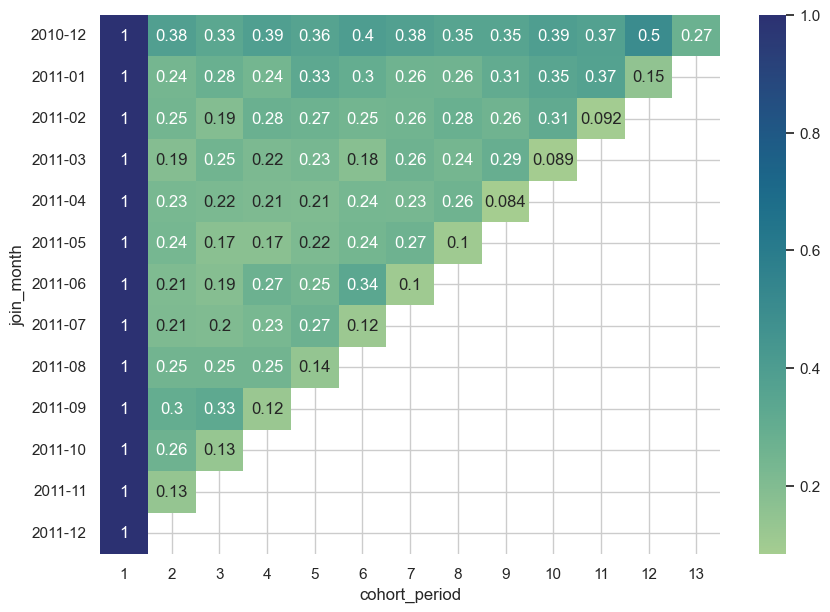

In [57]:
plt.figure(figsize=(10, 7))
sns.heatmap(retention_rate,annot=True,cmap="crest")
plt.show()

Маленькие показатели в последний месяц связаны с тем, что данные есть не по всему месяцу.

In [102]:
data_without_cancels.tail(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,FullPrice
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85


Также выделяется декабрь 2010 года, что может быть связано с тем, что это первый период и в могут входить покупатели за прошлые периоды, которых нету в данных.

Нельзя сказать, что удержание клиентов растет или падает. Перекосы в определенные периоды может быть связано с переодичностью покупок.

Также можно заметить, что показатель удержания одного месяца увеличывается со временем. основным товаром магазина являются уни кальные подарки и 
можно предположить, что спрос у определенного покупателя возникает во время праздников, они покупают товар и возвращаются через несколько месяцов.

### RFM-анализ

In [106]:
print('Начальная дата', data['InvoiceDate'].min(), 'Конечная дата', data['InvoiceDate'].max())

Начальная дата 2010-12-01 08:26:00 Конечная дата 2011-12-09 12:50:00


In [110]:
recency = (dt.datetime(2010, 12, 9) - data_without_cancels.groupby('CustomerID').agg({'InvoiceDate':'max'})).rename(columns = {'InvoiceDate':'Recency'})
recency['Recency'] = abs(recency['Recency'].dt.days)
recency.head()

,Recency
CustomerID,
12346,41
12347,364
12348,291
12349,348
12350,56


In [112]:
freq = data_without_cancels.groupby('CustomerID').agg({'InvoiceDate':'nunique'}).rename(columns={'InvoiceDate': 'Frequency'})
freq.head()

,Frequency
CustomerID,
12346,1
12347,7
12348,4
12349,1
12350,1


In [114]:
monetary = data_without_cancels.groupby('CustomerID').agg({'FullPrice':'sum'}).rename(columns={'FullPrice':'Monetary'})
monetary.head()

,Monetary
CustomerID,
12346,77183.60
12347,4310.00
12348,1797.24
12349,1757.55
12350,334.40


In [116]:
rfm = pd.concat([recency, freq, monetary],  axis=1)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,41,1,77183.60
12347,364,7,4310.00
12348,291,4,1797.24
12349,348,1,1757.55
12350,56,1,334.40


In [118]:
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 3, labels = [3, 2, 1])

rfm['FrequencyScore']= pd.qcut(rfm['Frequency'].rank(method="first"),3, labels=[1,2,3])

rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'], 3, labels = [1, 2, 3])


rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore
CustomerID,,,,,,
12346,41,1,77183.60,3,1,3
12347,364,7,4310.00,1,3,3
12348,291,4,1797.24,2,2,3
12349,348,1,1757.55,1,1,3
12350,56,1,334.40,3,1,1


In [120]:
rfm['RFM_SCORE'] = (rfm['RecencyScore'].astype(str) + 
                     rfm['FrequencyScore'].astype(str) + 
                     rfm['MonetaryScore'].astype(str))
rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
CustomerID,,,,,,,
12346,41,1,77183.60,3,1,3,313
12347,364,7,4310.00,1,3,3,133
12348,291,4,1797.24,2,2,3,223
12349,348,1,1757.55,1,1,3,113
12350,56,1,334.40,3,1,1,311


In [122]:
rfm_graph = rfm.reset_index() \
               .groupby('RFM_SCORE', as_index=False) \
               .agg({'CustomerID': 'count'}) \
               .rename(columns={'CustomerID': 'num_of_customers'})
rfm_graph.head()

,RFM_SCORE,num_of_customers
0,111,128
1,112,32
2,113,3
3,121,102
4,122,235


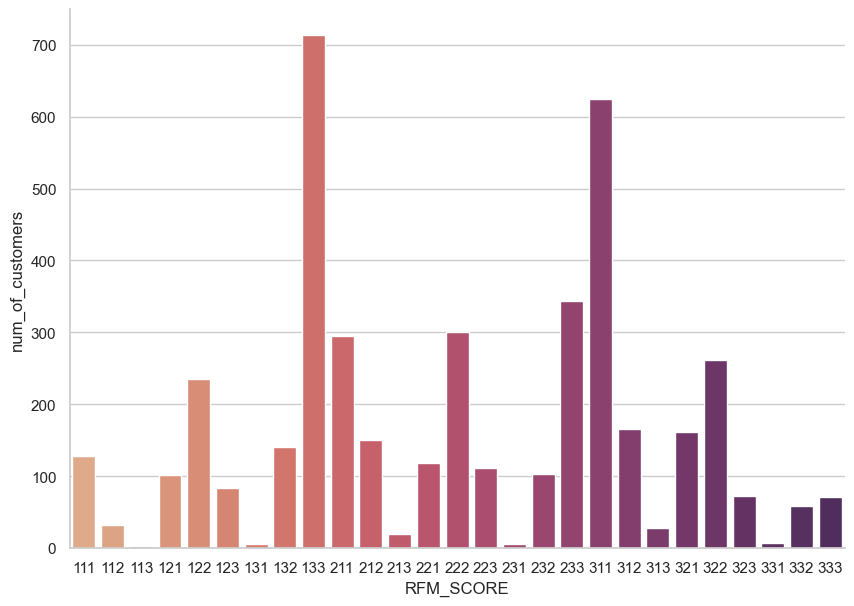

In [124]:
sns.color_palette("flare", as_cmap=True)
plt.figure(figsize=(10, 7))

sns.barplot(data=rfm_graph, x='RFM_SCORE', y='num_of_customers', palette="flare")
sns.despine()

Больше всего покупателей, которые покупали часто и на большие суммы, но давно, а также новые клиенты, которые покупали товар недавно один раз и не на большую сумму.